In [1]:
import loompy as lp
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pdir = "/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/"
MODULE_PATH = pdir+"processed-data/09_SCENIC/AUCell_regulons/"

In [12]:
def extract_aucell(cluster):
    lf = lp.connect(MODULE_PATH+"spe-n119_seurat-label-"+cluster+"_13162-genes_no-lowUMI_logcounts_regulons-weighted_AUCell-fixed-thold-05.loom", mode='r+', validate=False)
    auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
    cell_mtx = pd.DataFrame({"seurat_label": lf.ca.seurat_label, "smoothed_k9_1663": lf.ca.smoothed_k9_1663, #"custom_cluster": cluster,
                             "sex": lf.ca.sex, "condition": lf.ca.condition, "nGene": lf.ca.nGene, "nUMI": lf.ca.nUMI}, index=lf.ca.CellID)
    lf.close()
    
    #signature_column_names = list(auc_mtx.select_dtypes('number').columns)
    #signature_column_names = list(map(lambda s: s[12:], signature_column_names))
    #auc_mtx.columns = signature_column_names
    
    return auc_mtx, cell_mtx

In [14]:
auc_mv, cell_mv = extract_aucell("Micro.Vasc")
auc_ast, cell_ast = extract_aucell("Astro")
auc_l23, cell_l23 = extract_aucell("L2.3")
#auc_agl, cell_agl = extract_aucell("custom-cluster-", "Astro.Glia")
#auc_anr, cell_anr = extract_aucell("custom-cluster-", "Astro.Nrn")
#auc_l2, cell_l2 = extract_aucell("custom-cluster-", "L2")
#auc_l3, cell_l3 = extract_aucell("custom-cluster-", "L3")
auc_l4, cell_l4 = extract_aucell("L4")
auc_inh, cell_inh = extract_aucell("Inhb")
auc_l5, cell_l5 = extract_aucell("L5")
auc_l6, cell_l6 = extract_aucell("L6")
auc_wm, cell_wm = extract_aucell("Oligo")

In [15]:
auc_all = pd.concat([auc_mv, auc_ast, auc_l23, #auc_agl, auc_anr, auc_l2, auc_l3, 
                     auc_l4, auc_inh, auc_l5, auc_l6, auc_wm])
cell_all = pd.concat([cell_mv, cell_ast, cell_l23, #cell_agl, cell_anr, cell_l2, cell_l3, 
                      cell_l4, cell_inh, cell_l5, cell_l6, cell_wm])

In [16]:
joined_all = pd.concat([auc_all, cell_all], axis=1)
joined_all.shape

(513200, 36)

In [17]:
joined_all.to_csv(pdir+"processed-data/09_SCENIC/spe-n119_13162-no-lowUMI_logcounts_regulons-weighted_AUCell.csv")

In [8]:
import pickle
with open('/dcs04/lieber/marmaypag/spatialDLPFC_mdd_bpd_LIBD4100/spatialDLPFC_mdd_bpd/processed-data/09_SCENIC/spe-n119_13162-no-lowUMI_logcounts.regulons-weighted.dat', 'rb') as file:
    regulons = pickle.load(file)

In [9]:
reg_df = pd.DataFrame({"TF": [item.transcription_factor for item in regulons],
                       "dir": ["activating" if "activating" in item.context else "repressing" for item in regulons],
                       "set_size": [len(item) for item in regulons],
                      "set_str": ['/' .join(list(item.genes)) for item in regulons]})

In [10]:
reg_df

,TF,dir,set_size,set_str
0,ARX,activating,11,SP9/MYO5B/KCNS3/LHX6/TAC1/AKAIN1/ARX/NXPH1/GAD...
1,ATF3,activating,18,ZIC4/RRAD/EMP1/VWF/MUSTN1/IFITM1/ITGA5/ADAMTS1...
2,BCL6,activating,7,CHI3L1/ADAM28/HK2/BCL6/FAM189A2/CD44/MTRNR2L1
3,CEBPB,activating,11,NEXN/CP/CYP1B1/S100A8/CD14/CEBPB/S100A9/DDX60/...
4,CEBPD,activating,28,IGFBP4/OSMR/IFITM3/TGFBI/CDKN1A/CRISPLD2/LRRC3...
5,CUX2,activating,10,FREM3/LINC00507/RCN1/RASGRF2/EPHA6/NEUROD1/GRB...
6,DLX1,activating,18,NR2F2/DLX6-AS1/SOX1/DLX2/PENK/DLX5/DLX6/DLX1/E...
7,ETS2,activating,13,GLI3/TESPA1/LMO4/RGS4/ENC1/GAP43/RCAN2/ZNF682/...
8,FOS,activating,100,ATF3/HSPA1A/DUSP1/GADD45B/ZFP36/NR4A1/HSPA1B/R...
9,FOSB,activating,9,NPAS4/EGR4/INHBA/EGR1/FOS/RGS2/BDNF/FOSB/GADD45B


In [11]:
reg_df.to_csv(pdir+"processed-data/09_SCENIC/spe-n119_13162-no-lowUMI_logcounts_regulons-weighted_merged.csv")

In [18]:
transfer_bright = {'Micro.Vasc': "#911223", 'Astro': "#cfa45c", 'L2.3': "#088F8F", 'L4': "#c2cfcf",
                   'Inhb': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'Oligo': "#D1C4B0"}
smoothed_bright = {'Vasc': "#911223", 'L1': "#cfa45c", 'L2': "#5D9940", 'L3.4': "#5095CD",
                  'GABA': "#9377AC", 'L5': "#ddc94e", 'L6': "#E45C5F", 'WM': "#D1C4B0"}

In [19]:
joined_precast = joined_all.loc[-joined_all['smoothed_k9_1663'].isin(['Vasc','GABA'])]
joined_precast.shape

(508372, 36)

In [20]:
auc_all.columns

Index(['ARX(+)', 'ATF3(+)', 'BCL6(+)', 'CEBPB(+)', 'CEBPD(+)', 'CUX2(+)',
       'DLX1(+)', 'ETS2(+)', 'FOS(+)', 'FOSB(+)', 'IRF9(+)', 'JUN(+)',
       'JUNB(+)', 'JUND(+)', 'KLF2(+)', 'KLF4(+)', 'LHX2(+)', 'LHX6(+)',
       'MAFF(+)', 'MBNL2(+)', 'NEUROD1(+)', 'NPAS4(+)', 'NR2F2(+)', 'SOX10(+)',
       'SOX2(+)', 'SOX8(+)', 'SOX9(+)', 'SREBF1(+)', 'THRA(+)', 'ZBTB7A(+)'],
      dtype='object')

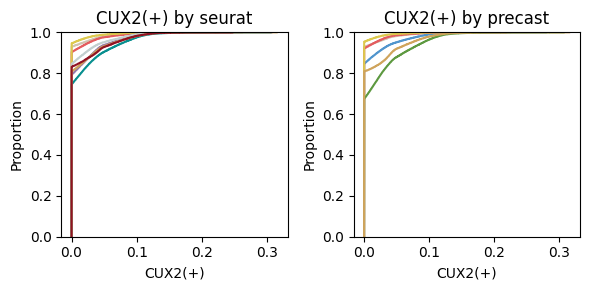

In [21]:
gene1 = "CUX2(+)" #49 module genes

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

In [23]:
sns.set_theme(font_scale=.7)

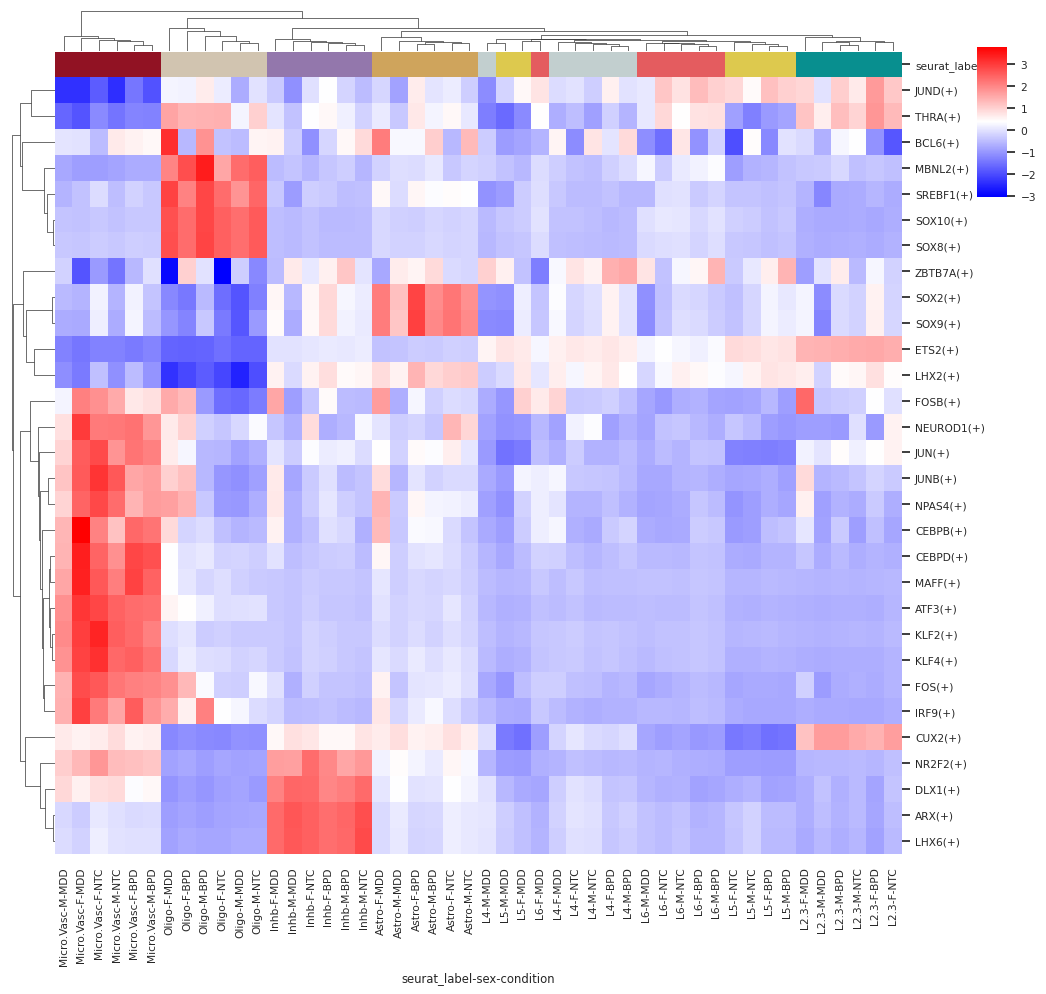

In [24]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['seurat_label','sex','condition']]
df_means = df_scores.groupby(by=['seurat_label','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['seurat_label'] = [x[0] for x in df_means.index]
row_colors = colors_df['seurat_label'].map(transfer_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

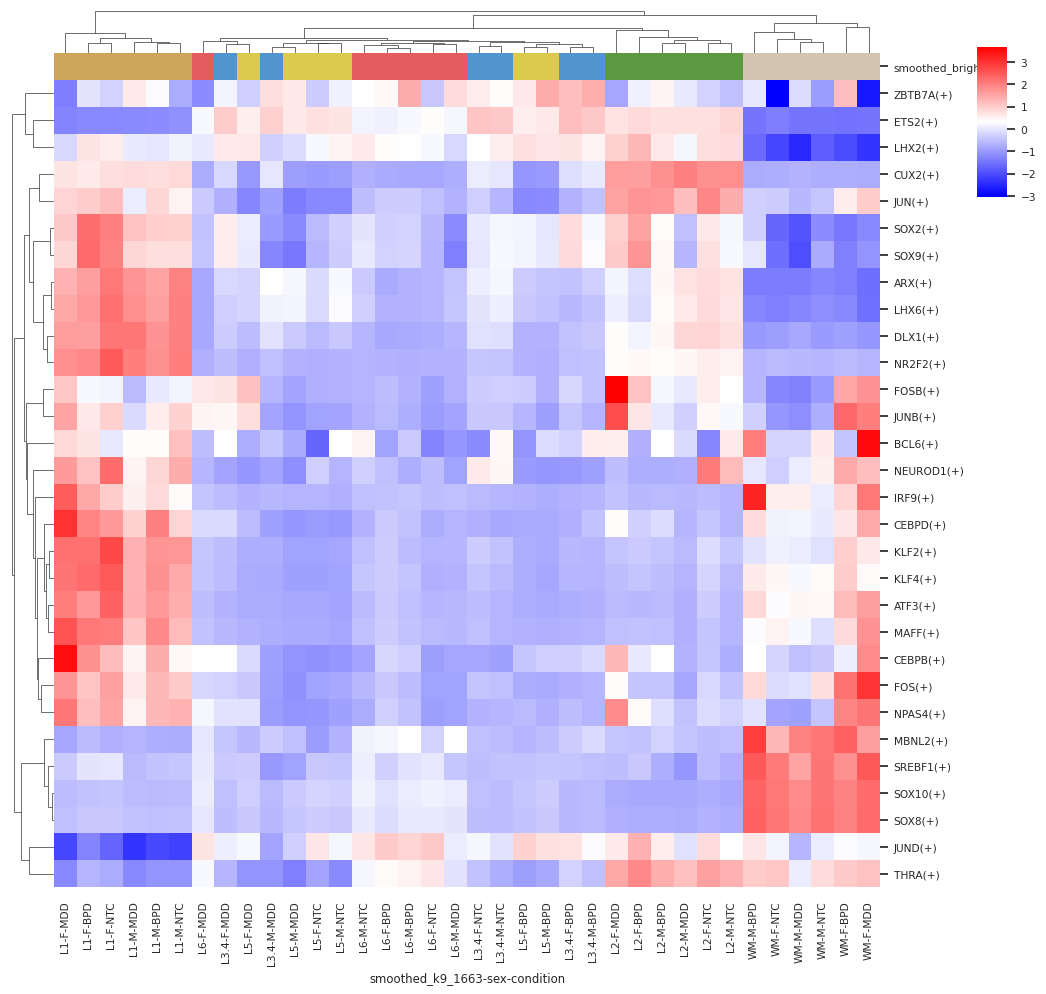

In [25]:
df_scores = joined_all[list(auc_all.select_dtypes('number').columns)+['smoothed_k9_1663','sex','condition']]
df_scores = df_scores.loc[-df_scores['smoothed_k9_1663'].isin(['Vasc','GABA'])]
df_means = df_scores.groupby(by=['smoothed_k9_1663','sex','condition']).mean()

colors_df = pd.DataFrame(index=df_means.index)
colors_df['smoothed_bright'] = [x[0] for x in df_means.index]
row_colors = colors_df['smoothed_bright'].map(smoothed_bright)

sns.clustermap(df_means.T, z_score='row', col_colors=row_colors, dendrogram_ratio=.05,
               cmap='bwr',
              cbar_pos=(0.98, 0.8, 0.03, 0.15))

In [ ]:
['KLF2','SOX2','LHX6','SOX8(+)']

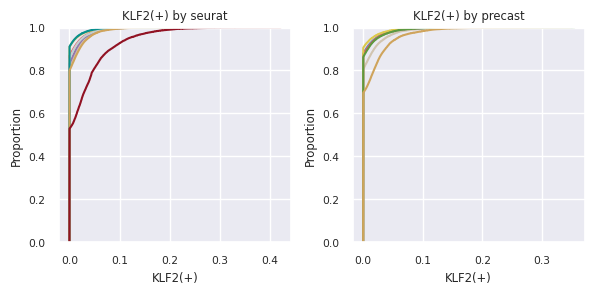

In [26]:
gene1 = "KLF2(+)" #VASC

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

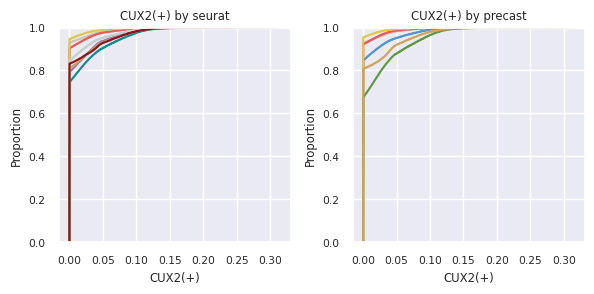

In [31]:
gene1 = "CUX2(+)" #VASC

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

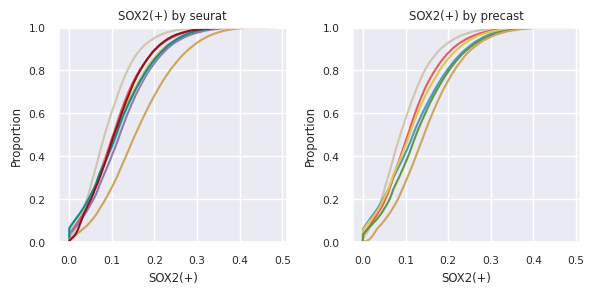

In [27]:
gene1 = "SOX2(+)" #ASTRO

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

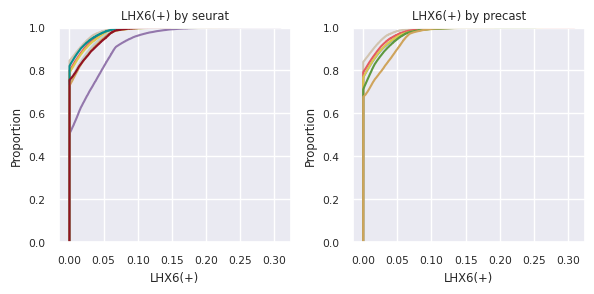

In [28]:
gene1 = "LHX6(+)" #inhb

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

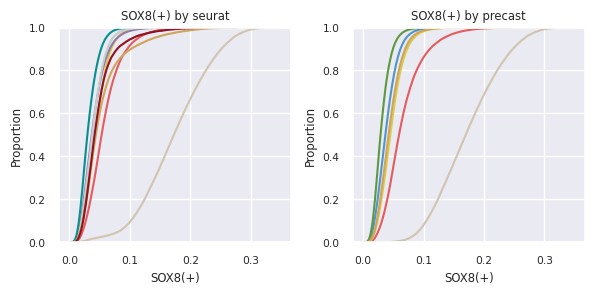

In [30]:
gene1 = "SOX8(+)" #OLIG

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.ecdfplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.ecdfplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

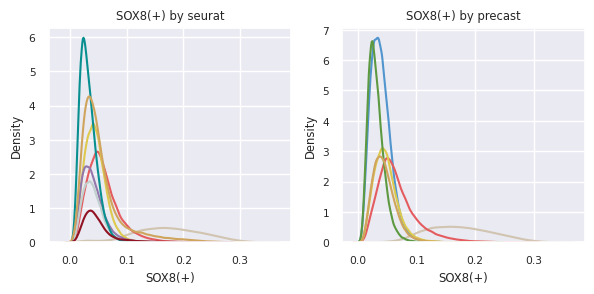

In [33]:
gene1 = "SOX8(+)" #Oligo

fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(6, 3))
sns.kdeplot(data=joined_all, x=gene1, hue="seurat_label", palette=transfer_bright, legend=False, ax=ax1)
ax1.set_title(gene1+" by seurat")
sns.kdeplot(data=joined_precast, x=gene1, hue="smoothed_k9_1663", palette=smoothed_bright, legend=False, ax=ax2)
ax2.set_title(gene1+" by precast")

plt.tight_layout()

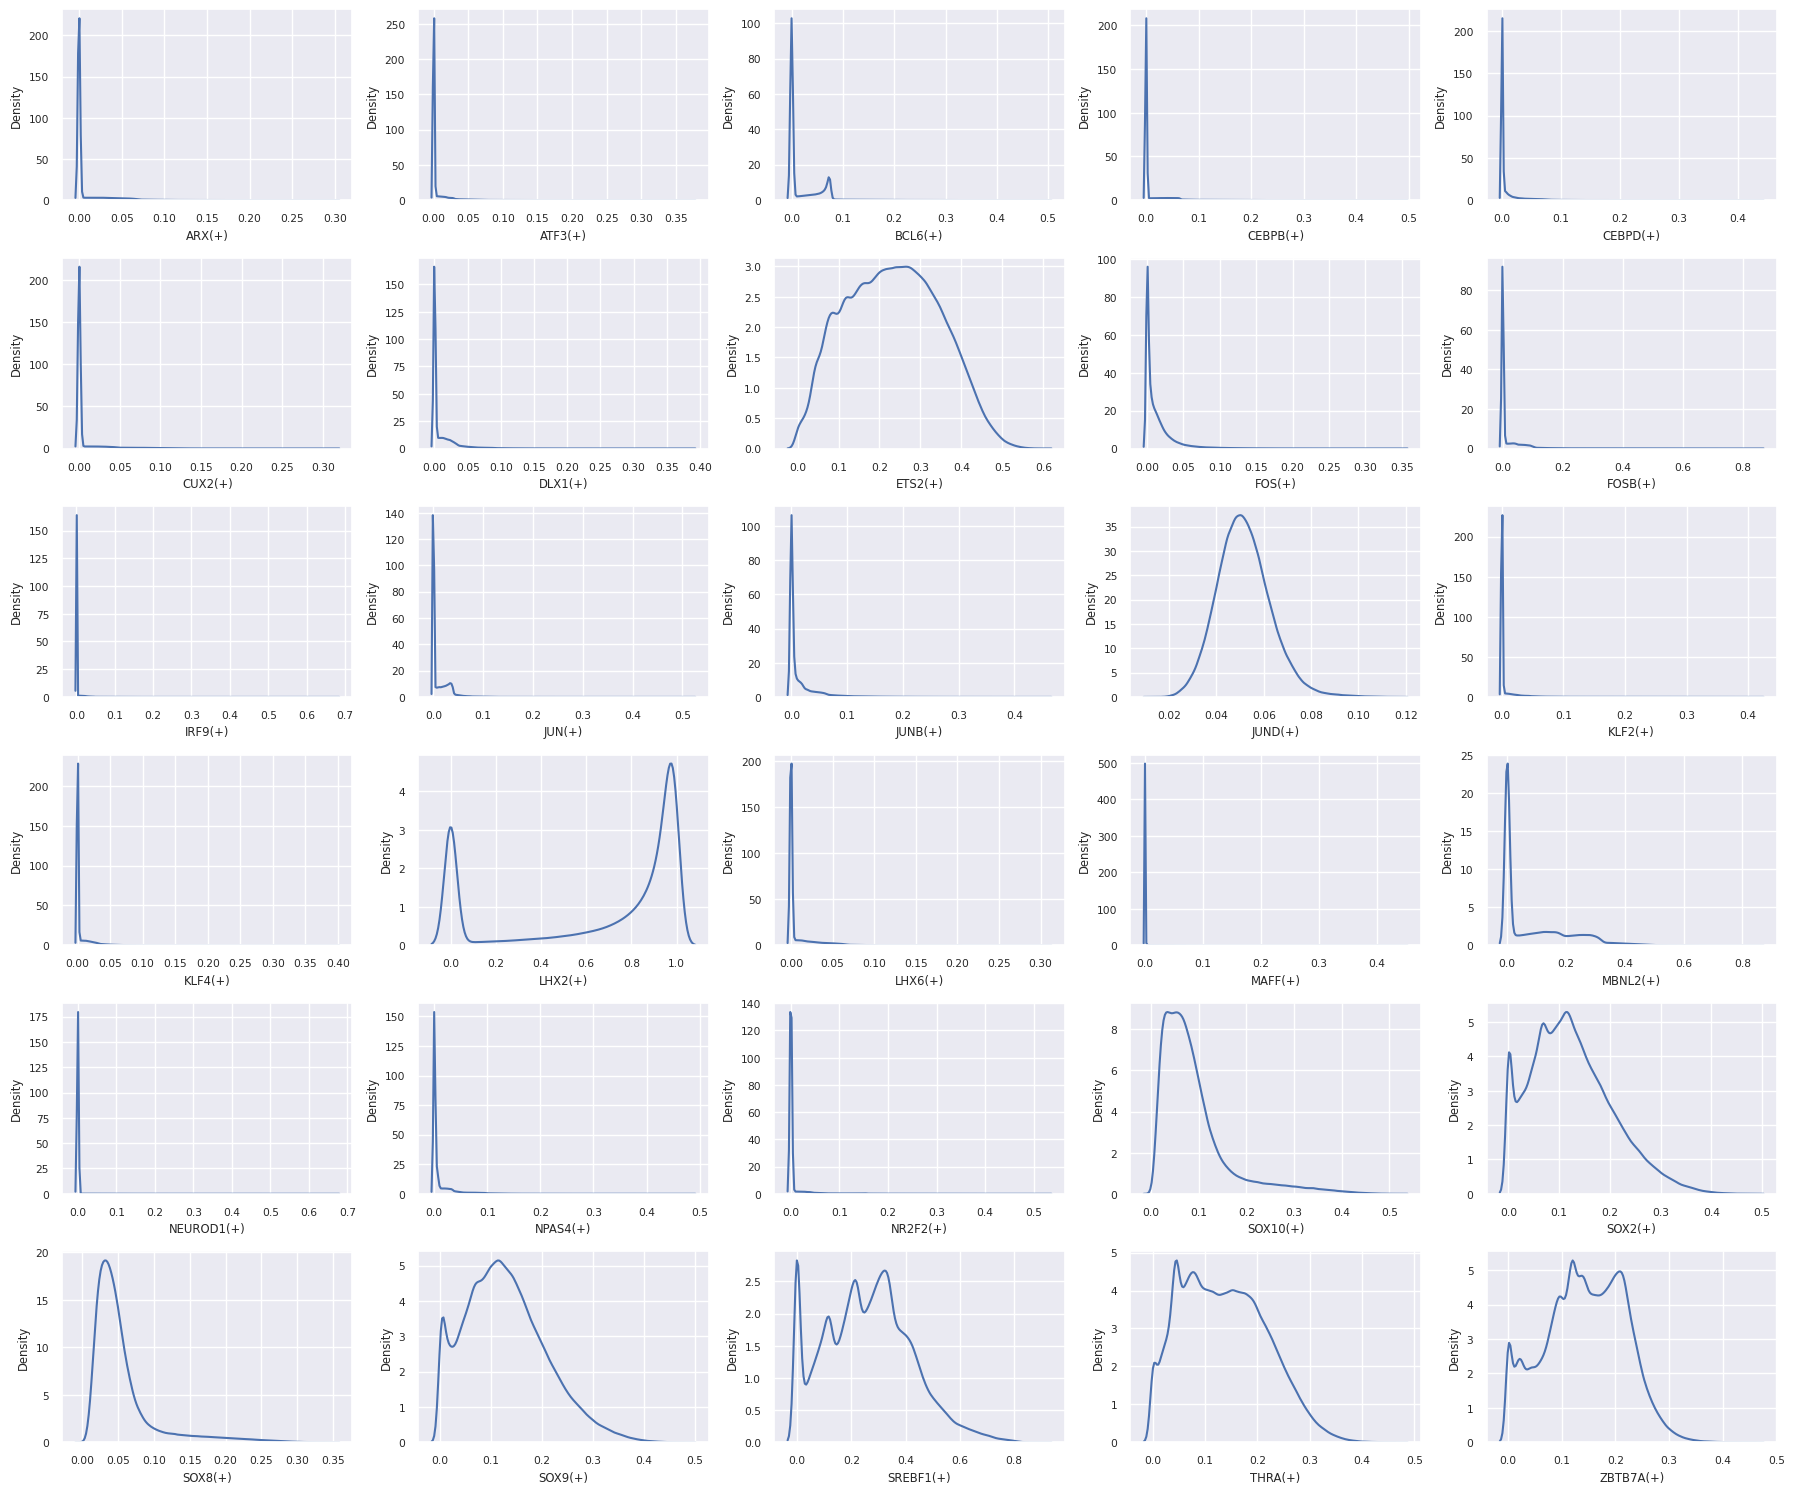

In [32]:
fig, axs = plt.subplots(6, 5, figsize=(18, 15))

axs_flat = axs.flatten()

for i in range(30):
    gene1 = auc_all.columns[i]
    
    sns.kdeplot(data=joined_all, x=gene1, ax=axs_flat[i])

plt.tight_layout()
plt.show()

In [24]:
#unimodal: THRB, GTF2I
# from source code this is their thresholding method for unimodal

auc_all['GTF2I(+)'].mean() + 2.0 * auc_all['GTF2I(+)'].std()

0.15615375083348051

In [40]:
from pyscenic.binarization import binarize

In [65]:
bin_all, thresholds_all = binarize(auc_scale)

/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic_bioconda/lib/python3.10/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(
/users/jthompso/.conda/envs/pyscenic

In [54]:
def plot_binarization(
    auc_mtx: pd.DataFrame, regulon_name: str, threshold: float, bins: int = 200, ax=None
) -> None:
    """
    Plot the "binarization" process for the given regulon.

    :param auc_mtx: The dataframe with the AUC values for all cells and regulons (n_cells x n_regulons).
    :param regulon_name: The name of the regulon.
    :param bins: The number of bins to use in the AUC histogram.
    :param threshold: The threshold to use for binarization.
    """
    if ax is None:
        ax = plt.gca()
    sns.histplot(auc_mtx[regulon_name], ax=ax, #norm_hist=True, 
                 bins=bins)

    ylim = ax.get_ylim()
    ax.plot([threshold] * 2, ylim, "r:")
    ax.set_ylim(ylim)
    ax.set_xlabel("AUC")
    ax.set_ylabel("#")
    ax.set_title(regulon_name)


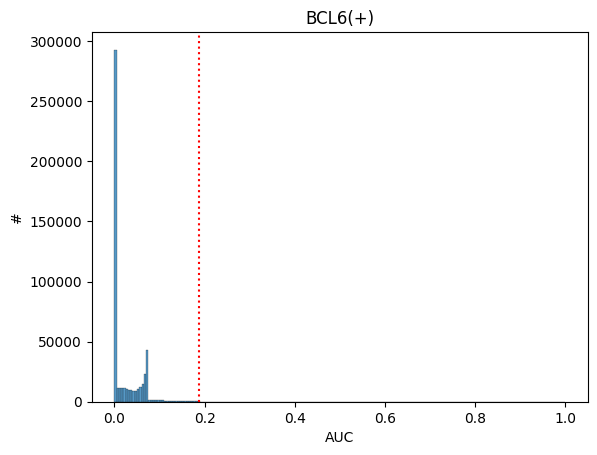

In [66]:
plot_binarization(auc_scale, "BCL6(+)", thresholds_all['BCL6(+)'])

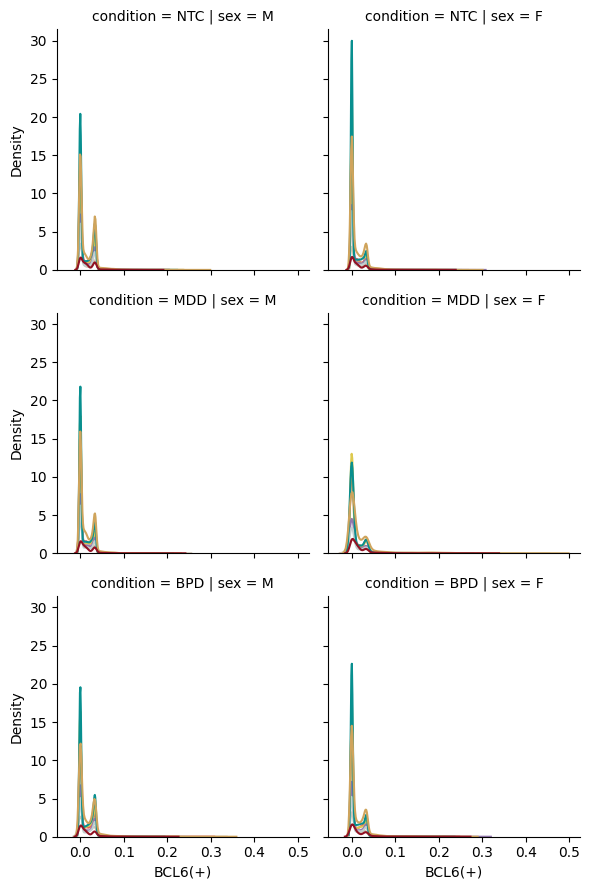

In [37]:
g = sns.FacetGrid(joined_all, col="sex",  row="condition")
g.map_dataframe(sns.kdeplot, x="BCL6(+)", hue="seurat_label", palette=transfer_bright)

In [34]:
joined_all['BCL6(+)']

TAGAATAGCCGATGAA-1_V13F27-338_A1    0.000000
CAACCTACCGAGCAGT-1_V13F27-338_A1    0.009600
GTCAACCAGGCCTATA-1_V13F27-338_A1    0.004672
CTAGGTCTGAAGGAAT-1_V13F27-338_A1    0.000000
CACCGTATCCCATCCG-1_V13F27-338_A1    0.007701
                                      ...   
CCAGTCTAGACGGCGC-1_V13B23-282_D1    0.000000
TCGCTTTAAACGTTTG-1_V13B23-282_D1    0.001027
AGTTACTCTATCGTGG-1_V13B23-282_D1    0.015813
GTGGCTGTTTCTGTTC-1_V13B23-282_D1    0.001643
CGTCGGATAGTGTTGA-1_V13B23-282_D1    0.016737
Name: BCL6(+), Length: 513200, dtype: float64